# Day 2

Today, we will start using nf-core pipelines to find differentially abundant genes in our dataset. 
We are using data from the following paper: https://www.nature.com/articles/s41593-023-01350-3#Sec10

1. Please take some time to read through the paper and understand their approach, hypotheses and goals.

The study uses a mouse model of chronic neuropathic pain to investigate the behavioral and transcriptomic effects of oxycodone withdrawal in reward brain regions, hypothesizing that HDAC1/HDAC2 drive these maladaptations and testing an HDAC inhibitor (RBC1HI) to reverse withdrawal symptoms

What was the objective of the study?

1. Characterize the behavioral and molecular effects of chronic oxycodone exposure in mice, with and without chronic neuropathic pain.
2. Identify the transcriptional adaptations in three reward-related brain regions (NAc, mPFC, VTA) and determine how chronic pain modifies them.
3. Test a pharmacological intervention based on bioinformatic predictions: specifically, a novel HDAC1/HDAC2 inhibitor (RBC1HI)

What do the conditions mean?

oxy: is the abbreviation for the oxycodone treatment<br>
sal: is the abbreviation for the treatment using the vehicle control (i.e. sterile 0.9% saline solution)

What do the genotypes mean?

These are not genotypes (All mice are C57BL/6J wild-type).

SNI: The sciatic nerve branches are ligated and cut, producing chronic neuropathic pain.<br>
Sham:  No nerve injury, so no chronic neuropathic pain.

Imagine you are the bioinformatician in the group who conducted this study. They hand you the raw files and ask you to analyze them.


What would you do?

I would analize the changes of the gene expression int all the 4 cases higlighting wich problems in trascription are related with the clynical labels and after that I´ll compare the most ill gropu genes expression with the less ill group.


I would analyze the changes in gene expression in all four experimental groups (Sham-Sal, Sham-Oxy, SNI-Sal, SNI-Oxy), highlighting which transcriptional changes are associated with the experimental conditions.
Running the pipeline of the "day_1": nf-core/differentialabundance on the dataset will display most of this informations.

I would compare:

Oxy vs Sal
→ all Oxy samples vs all Sal samples, regardless of SNI/Sham.<br>
Expected outcome: gene expression changes driven by chronic oxycodone exposure and withdrawal, including synaptic plasticity and chromatin regulation genes in reward regions.<br>

Oxy-SNI vs oxy-Sham
→ all SNI samples vs all Sham samples with oxy label<br>
Expected outcome: effect of neuropathic pain specifically under oxycodone treatment.

Your group gave you a very suboptimal excel sheet (conditions_runs_oxy_project.xlsx) to get the information you need for each run they uploaded to the SRA.<br>
So, instead of directly diving into downloading the data and starting the analysis, you first need to sort the lazy table.<br>
Use Python and Pandas to get the table into a more sensible order.<br>
Then, perform some overview analysis and plot the results
1. How many samples do you have per condition?
2. How many samples do you have per genotype?
3. How often do you have each condition per genotype?

Long-format table:


,sample,condition,genotype
0,SRR23195505,Sal,SNI
1,SRR23195506,Oxy,Sham
2,SRR23195507,Sal,Sham
3,SRR23195508,Oxy,SNI
4,SRR23195509,Oxy,SNI
5,SRR23195510,Sal,SNI
6,SRR23195511,Oxy,Sham
7,SRR23195512,Sal,Sham
8,SRR23195513,Sal,SNI
9,SRR23195514,Oxy,Sham



Samples per condition:
condition
Oxy    8
Sal    8
Name: count, dtype: int64


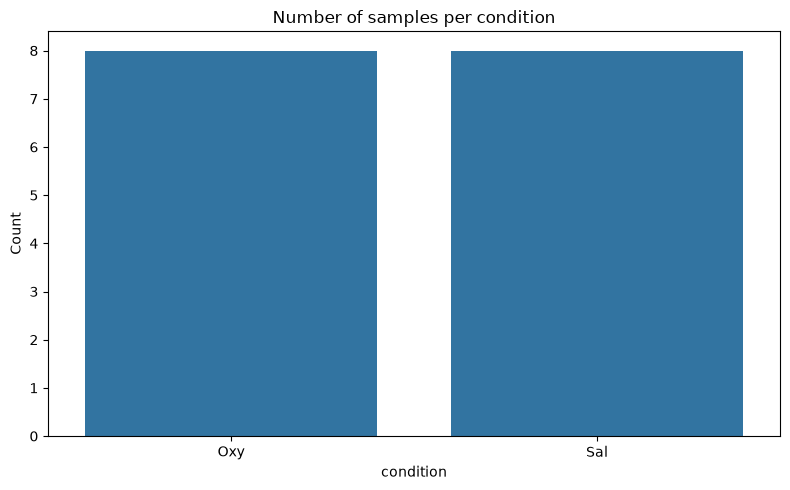

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------------
# Load the Excel file
# ---------------------------------------------------------------
df = pd.read_excel("conditions_runs_oxy_project.xlsx")
df = df.apply(lambda s: s.str.strip() if s.dtype == "object" else s)

# ---------------------------------------------------------------
# Reshape from WIDE to LONG format
# ---------------------------------------------------------------
id_cols = ["Patient", "Run"]
cond_cols = ["condition: Sal", "Condition: Oxy"]
geno_cols = ["Genotype: SNI", "Genotype: Sham"]

def is_positive(val):
    return pd.notna(val) and str(val).strip().lower() not in ["", "?", "nan", "0", "no", "false", "-", "none"]

def extract_category(row, cols):
    hits = [c.split(":")[-1].strip() for c in cols if is_positive(row[c])]
    if len(hits) > 1:
        print(f"Warning: multiple hits in row {row.name}: {hits}")
    return hits[0] if hits else np.nan

df_long = df[id_cols].copy()
df_long["condition"] = df.apply(lambda r: extract_category(r, cond_cols), axis=1)
df_long["genotype"]  = df.apply(lambda r: extract_category(r, geno_cols), axis=1)

# Use Run as sample ID (Patient column may be empty)
df_long["sample"] = df_long["Run"]

# Keep only RNA-seq samples (drop rows without condition or genotype)
df_long = df_long.dropna(subset=["condition", "genotype"]).reset_index(drop=True)

# Final column order
df_long = df_long[["sample", "condition", "genotype"]]

print("Long-format table:")
display(df_long)

# ---------------------------------------------------------------
# Q1: How many samples do you have per condition?
# ---------------------------------------------------------------
count_condition = df_long["condition"].value_counts().sort_index()
print("\nSamples per condition:")
print(count_condition)

plt.figure(figsize=(8, 5))
sns.barplot(x=count_condition.index, y=count_condition.values)
plt.title("Number of samples per condition")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Samples per genotype:
genotype
SNI     8
Sham    8
Name: count, dtype: int64


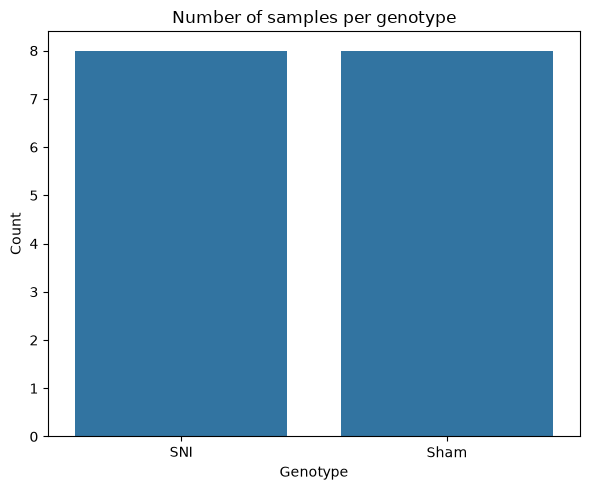

In [2]:
# ---------------------------------------------------------------
# Q2: How many samples do you have per genotype?
# ---------------------------------------------------------------
count_genotype = df_long["genotype"].value_counts().sort_index()
print("Samples per genotype:")
print(count_genotype)

plt.figure(figsize=(6, 5))
sns.barplot(x=count_genotype.index, y=count_genotype.values)
plt.title("Number of samples per genotype")
plt.xlabel("Genotype")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Condition per genotype:
condition  Oxy  Sal
genotype           
SNI          4    4
Sham         4    4


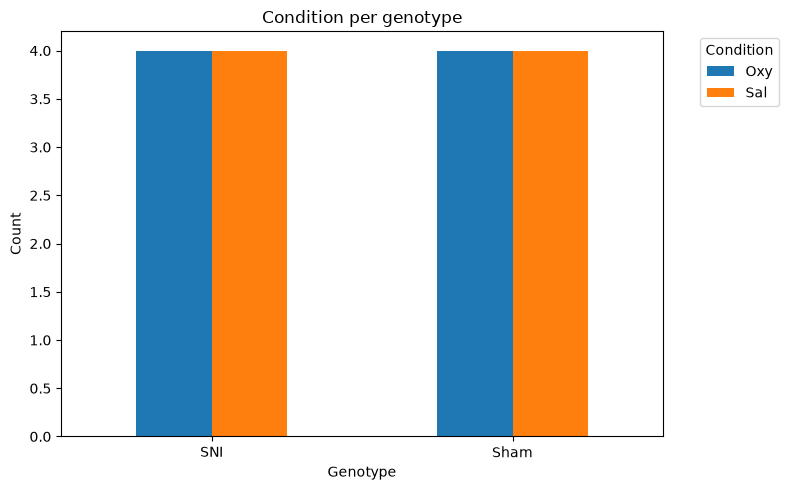

In [3]:
# ---------------------------------------------------------------
# Q3: How often do you have each condition per genotype?
# ---------------------------------------------------------------
count_cond_geno = (
    df_long
    .groupby(["genotype", "condition"])
    .size()
    .unstack(fill_value=0)
)
print("Condition per genotype:")
print(count_cond_geno)

plt.figure(figsize=(8, 5))
count_cond_geno.plot(kind="bar", stacked=False, ax=plt.gca())
plt.title("Condition per genotype")
plt.xlabel("Genotype")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

They were so kind to also provide you with the information of the number of bases per run, so that you can know how much space the data will take on your Cluster.<br>
Add a new column to your fancy table with this information (base_counts.csv) and sort your dataframe according to this information and the condition.

In [4]:
base_counts = pd.read_csv("base_counts.csv")
base_counts.columns = [c.strip() for c in base_counts.columns]
base_counts["Run"] = base_counts["Run"].astype(str).str.strip()

df_merged = df_long.merge(
    base_counts[["Run", "Bases"]],
    left_on="sample",
    right_on="Run",
    how="left"
).drop(columns=["Run"])
df_merged = df_merged.rename(columns={"Bases": "n_bases"})

df_sorted = df_merged.sort_values(
    by=["condition", "n_bases"],
    ascending=[True, False],
    ignore_index=True
)

print(df_sorted.to_string(index=False))

# Salva per il notebook 2
df_sorted.to_csv("metadata_long.csv", index=False)
print("\nSalvato: metadata_long.csv")

     sample condition genotype    n_bases
SRR23195506       Oxy     Sham 7859530800
SRR23195514       Oxy     Sham 7226808600
SRR23195509       Oxy      SNI 7003550100
SRR23195519       Oxy     Sham 6996050100
SRR23195508       Oxy      SNI 6927786900
SRR23195517       Oxy      SNI 6863840400
SRR23195511       Oxy     Sham 6456390900
SRR23195516       Oxy      SNI 6203117700
SRR23195515       Sal     Sham 8169101700
SRR23195513       Sal      SNI 8099181600
SRR23195507       Sal     Sham 8063298900
SRR23195518       Sal      SNI 7908500400
SRR23195520       Sal     Sham 7858146000
SRR23195512       Sal     Sham 7462857900
SRR23195510       Sal      SNI 7377388500
SRR23195505       Sal      SNI 6922564500

Salvato: metadata_long.csv


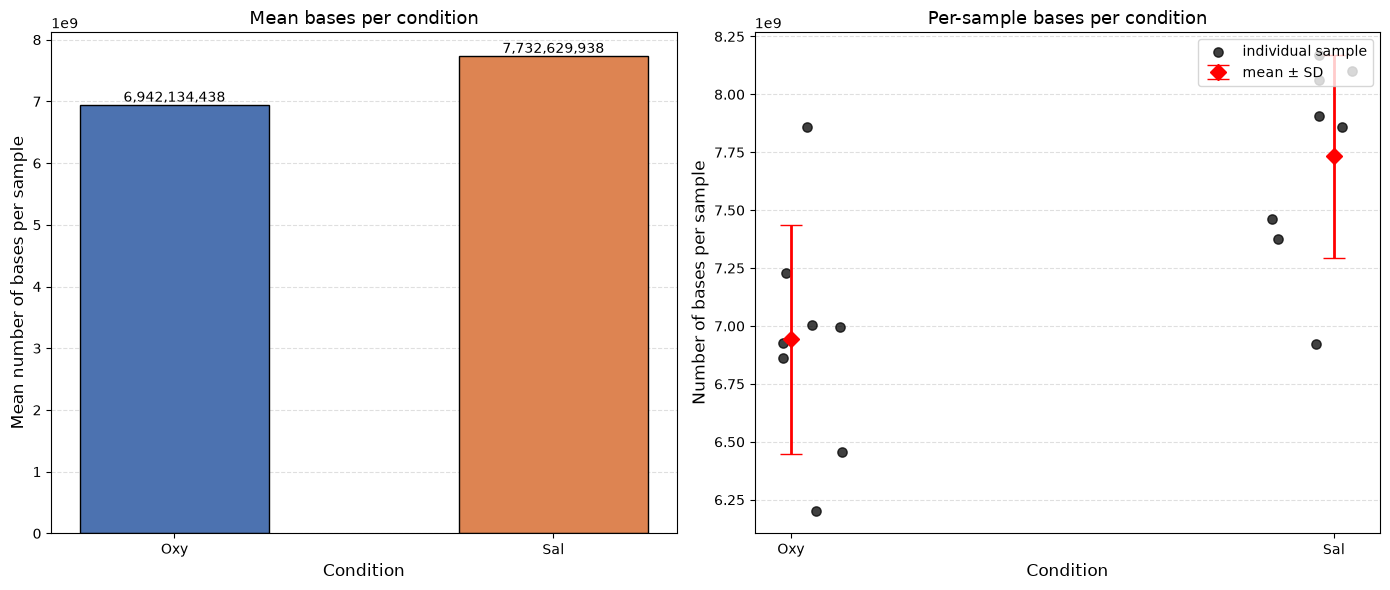

In [5]:
import numpy as np

np.random.seed(42)

means = df_sorted.groupby("condition")["n_bases"].mean()
stds  = df_sorted.groupby("condition")["n_bases"].std()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------- Panel 1: bar chart (means) ----------------
ax = axes[0]
bars = ax.bar(
    means.index,
    means.values,
    width=0.5,
    color=["#4C72B0", "#DD8452"],
    edgecolor="black",
    zorder=2
)
ax.set_title("Mean bases per condition", fontsize=13)
ax.set_xlabel("Condition", fontsize=12)
ax.set_ylabel("Mean number of bases per sample", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)

for bar, val in zip(bars, means.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val,
        f"{val:,.0f}",
        ha="center", va="bottom", fontsize=10
    )

# ---------------- Panel 2: points + mean ± SD ----------------
ax = axes[1]

for i, cond in enumerate(means.index):
    y_vals = df_sorted.loc[df_sorted["condition"] == cond, "n_bases"].values
    x_jitter = np.random.normal(i, 0.06, size=len(y_vals))

    # individual samples
    ax.scatter(
        x_jitter, y_vals,
        color="black", s=45, alpha=0.75, zorder=3,
        label="individual sample" if i == 0 else None
    )

    # mean ± SD
    ax.errorbar(
        i, means[cond], yerr=stds[cond],
        fmt="D", color="red", markersize=8,
        capsize=8, linewidth=2, zorder=4,
        label="mean ± SD" if i == 0 else None
    )

ax.set_title("Per-sample bases per condition", fontsize=13)
ax.set_xlabel("Condition", fontsize=12)
ax.set_ylabel("Number of bases per sample", fontsize=12)
ax.set_xticks(range(len(means.index)))
ax.set_xticklabels(means.index)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

Then select the 2 smallest runs from your dataset and download them from SRA (maybe an nf-core pipeline can help here?...)

In [6]:
# Ricrea srr_ids partendo da df_sorted (i 2 run più piccoli)
smallest = df_sorted.sort_values("n_bases").head(2)
srr_ids = smallest["sample"].tolist()
print("SRR IDs:", srr_ids)

SRR IDs: ['SRR23195516', 'SRR23195511']


In [7]:
with open("srr_ids.csv", "w") as f:
    for srr in srr_ids:
        f.write(f"{srr}\n")

# Config per nf-core/fetchngs: riduce la memoria richiesta (default 24 GB > 16 GB del Mac)
with open("fetchngs.config", "w") as f:
    f.write("process {\n")
    f.write("    withName: 'SRA_FASTQ_FTP'        { memory = '4 GB'; cpus = 2; time = '4h' }\n")
    f.write("    withName: 'SRATOOLS_PREFETCH'    { memory = '4 GB'; cpus = 2; time = '4h' }\n")
    f.write("    withName: 'SRATOOLS_FASTERQDUMP' { memory = '4 GB'; cpus = 2; time = '4h' }\n")
    f.write("}\n")

print("Salvati: srr_ids.csv, fetchngs.config")

Salvati: srr_ids.csv, fetchngs.config


In [8]:
!nextflow run nf-core/fetchngs \
    -profile docker \
    -c fetchngs.config \
    --input srr_ids.csv \
    --outdir results/fetchngs \
    -resume \
    -ansi-log false

N E X T F L O W  ~  version 26.04.6
WARN: It appears you have never run this project before -- Option `-resume` is ignored
Launching `https://github.com/nf-core/fetchngs` [elated_solvay] - revision: 955c892d80 [master]
WARN: Unrecognized config option 'manifest.diagram'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/fetchngs 1.13.0
------------------------------------------------------

Input/output options
  input              : srr_ids.csv
  outdir             : results/fetchngs

Deprecated options
  trace_report_suffix: 2026-09-30_13-38-30

Core Nextflow options
  revision           : master
  runName            : elated_solvay
  containerEngine    : docker
  launchDir          : /Users/tesbaro/Desktop/CompWorkflow/computat

While your files are downloading, get back to the paper and explain how you would try to reproduce the analysis.<br>
When you are done with this shout, so we can discuss the different ideas.

I would reproduce the analysis by using nf-core pipelines:<br>

Download raw data: fetchngs<br>
Alignment and quantification: rnaseq <br>
Differential expression: differentialabundance<br>
Functional enrichment: differentialabundance <br>
This covers the main steps of the paper: from raw reads to differentially expressed genes and enriched pathways. 